In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data-updated.csv')
display(df.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.879487,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [ ]:
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.879487,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.000000,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.400000,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.800000,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,30.556098,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.200000,Unknown,1


LOGISTIC **REGRESSION::**

Train stroke rate: 4.881%  |  Test stroke rate: 4.851%

=== Coefficients (standardised) ===
                       feature  coefficient  odds_ratio
                           age     1.871444    6.497674
            work_type_children     0.376141    1.456653
             avg_glucose_level     0.225293    1.252690
        work_type_Never_worked    -0.186856    0.829563
                  hypertension     0.166233    1.180848
         smoking_status_smokes     0.138584    1.148647
                        gender     0.102562    1.108006
       work_type_Self-employed    -0.098655    0.906055
   smoking_status_never smoked    -0.087436    0.916277
                Residence_type     0.058064    1.059783
smoking_status_formerly smoked     0.047185    1.048316
                 heart_disease     0.044620    1.045630
                           bmi     0.042205    1.043108
                  ever_married    -0.014719    0.985388
             work_type_Private    -0.007724    0.992306


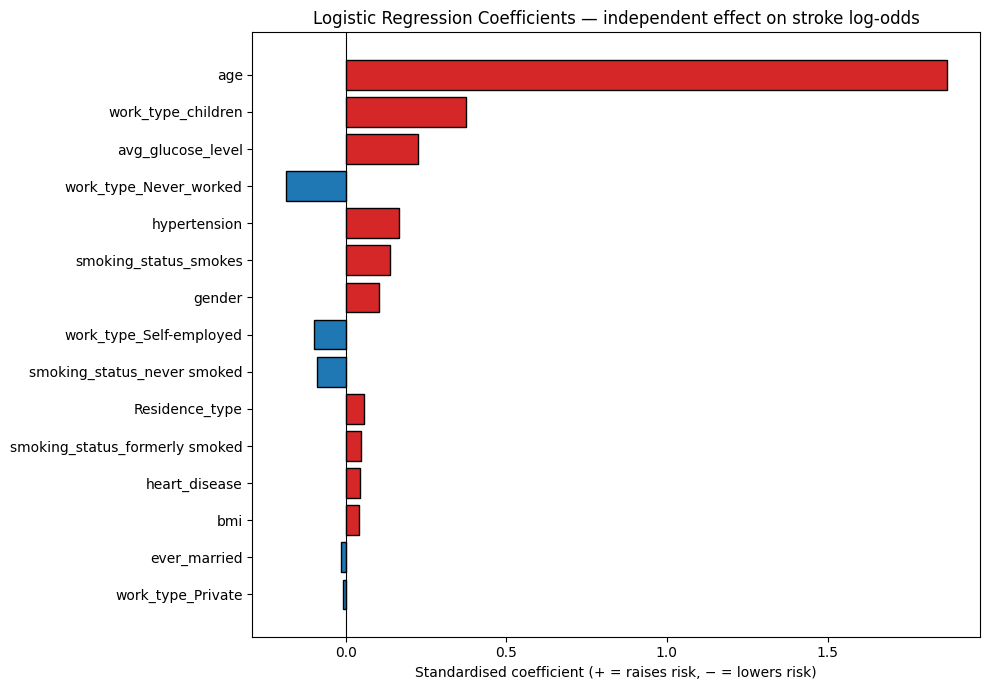


ROC-AUC: 0.845   |   Avg Precision (PR-AUC): 0.260

=== Classification report ===
              precision    recall  f1-score   support

   No Stroke       0.99      0.73      0.84      1216
      Stroke       0.13      0.79      0.22        62

    accuracy                           0.73      1278
   macro avg       0.56      0.76      0.53      1278
weighted avg       0.94      0.73      0.81      1278



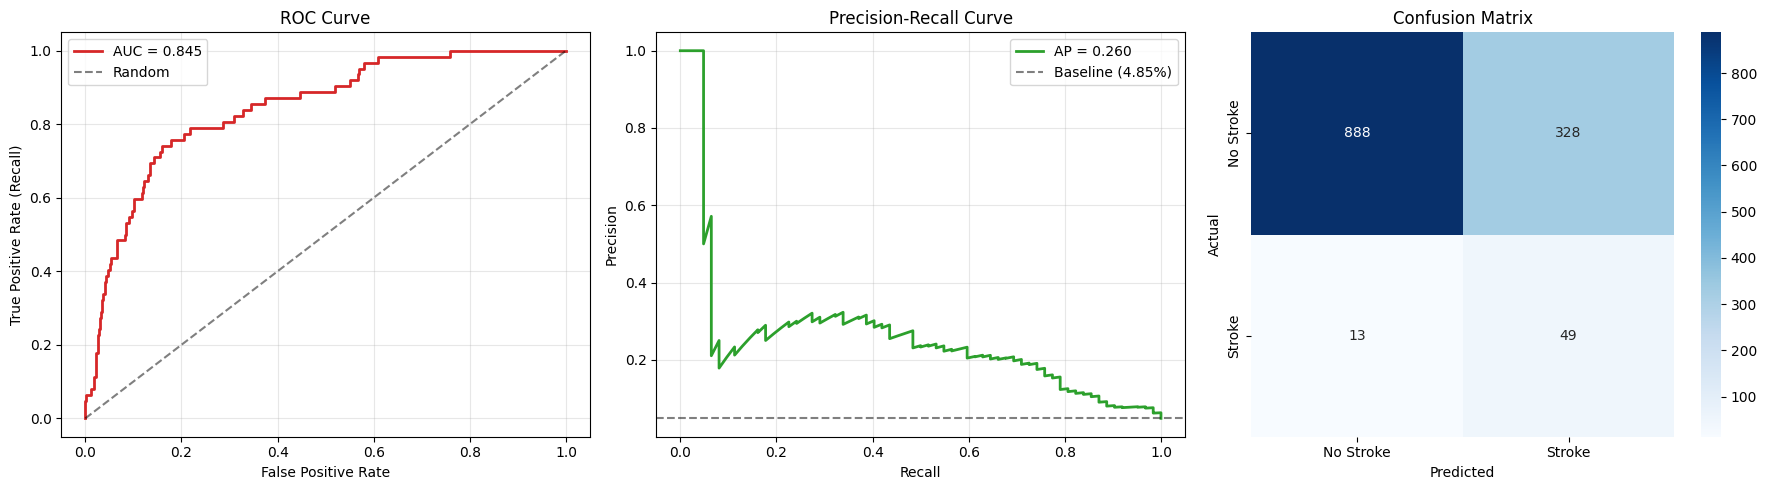

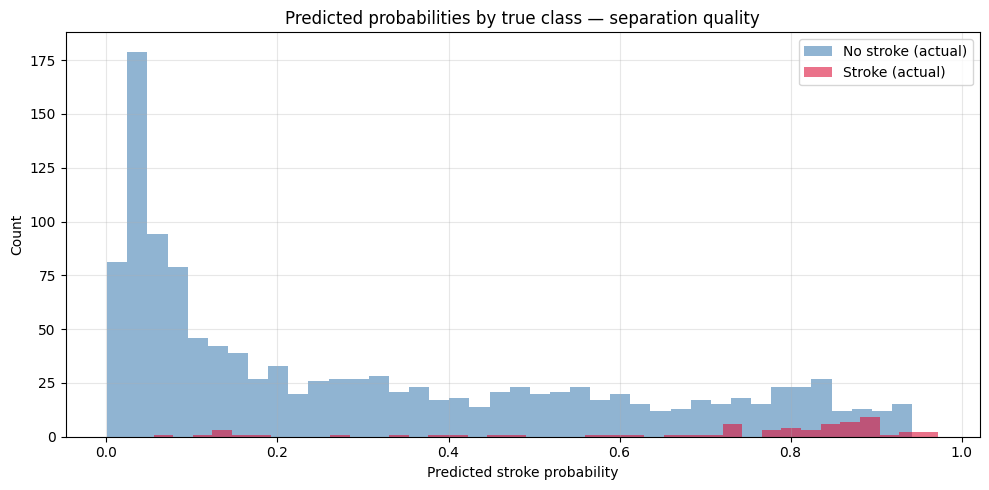

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, average_precision_score)

# ============================================================
# 1. PREP — same cleaning as before
# ============================================================
df_model = df.copy()
df_model['bmi'] = pd.to_numeric(df_model['bmi'], errors='coerce')
df_model['bmi'] = df_model['bmi'].fillna(df_model['bmi'].median())
df_model = df_model.drop(columns=['id'])

# Drop the single "Other" gender row if present — too few to model
df_model = df_model[df_model['gender'] != 'Other']

df_model['gender'] = df_model['gender'].map({'Male': 0, 'Female': 1})
df_model['ever_married'] = df_model['ever_married'].map({'No': 0, 'Yes': 1})
df_model['Residence_type'] = df_model['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_model = pd.get_dummies(df_model, columns=['work_type', 'smoking_status'], drop_first=True)

X = df_model.drop(columns=['stroke'])
y = df_model['stroke']

# ============================================================
# 2. TRAIN/TEST SPLIT — stratified to preserve the 5% base rate
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Standardise — coefficients become comparable in magnitude (like z-scored factor loadings)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train stroke rate: {y_train.mean():.3%}  |  Test stroke rate: {y_test.mean():.3%}")

# ============================================================
# 3. FIT — class_weight='balanced' handles the imbalance
# ============================================================
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# ============================================================
# 4. COEFFICIENTS — read these like factor loadings
# ============================================================
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)

print("\n=== Coefficients (standardised) ===")
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients — independent effect on stroke log-odds')
plt.xlabel('Standardised coefficient (+ = raises risk, − = lowers risk)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# 5. PREDICT & EVALUATE — out of sample
# ============================================================
y_pred_proba = model.predict_proba(X_test_s)[:, 1]
y_pred = model.predict(X_test_s)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
print(f"\nROC-AUC: {auc:.3f}   |   Avg Precision (PR-AUC): {ap:.3f}")
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

# ============================================================
# 6. THE THREE CHARTS THAT MATTER
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#d62728', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall curve — more informative than ROC when classes are imbalanced
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#2ca02c', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5,
                label=f'Baseline ({y_test.mean():.2%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# ============================================================
# 7. PROBABILITY DISTRIBUTION — how well-separated are the classes?
# ============================================================
plt.figure(figsize=(10, 5))
plt.hist(y_pred_proba[y_test == 0], bins=40, alpha=0.6, label='No stroke (actual)', color='steelblue')
plt.hist(y_pred_proba[y_test == 1], bins=40, alpha=0.6, label='Stroke (actual)', color='crimson')
plt.xlabel('Predicted stroke probability')
plt.ylabel('Count')
plt.title('Predicted probabilities by true class — separation quality')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XG BOOST FEATURES

scale_pos_weight = 19.49  (up-weights strokes by this factor)
Best iteration: 39  (stopped adding trees here)

ROC-AUC: 0.828   |   PR-AUC: 0.197

=== Classification report ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.70      0.81      1216
      Stroke       0.11      0.76      0.20        62

    accuracy                           0.70      1278
   macro avg       0.55      0.73      0.51      1278
weighted avg       0.94      0.70      0.78      1278



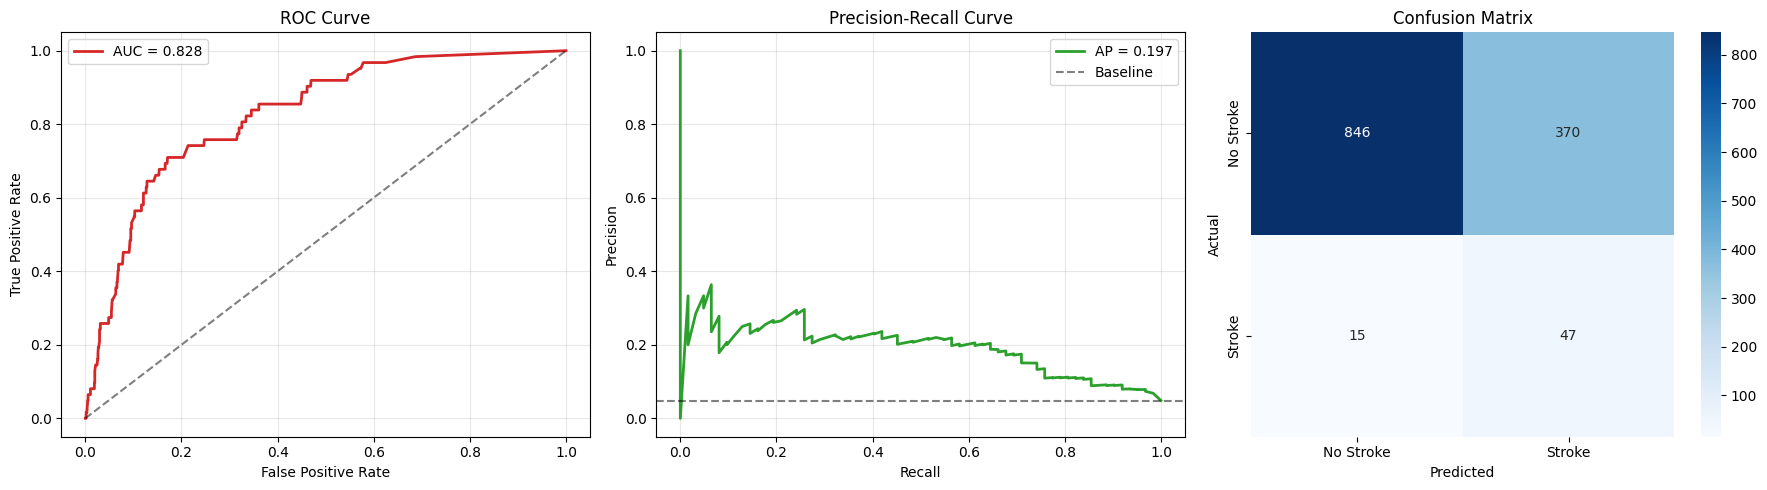

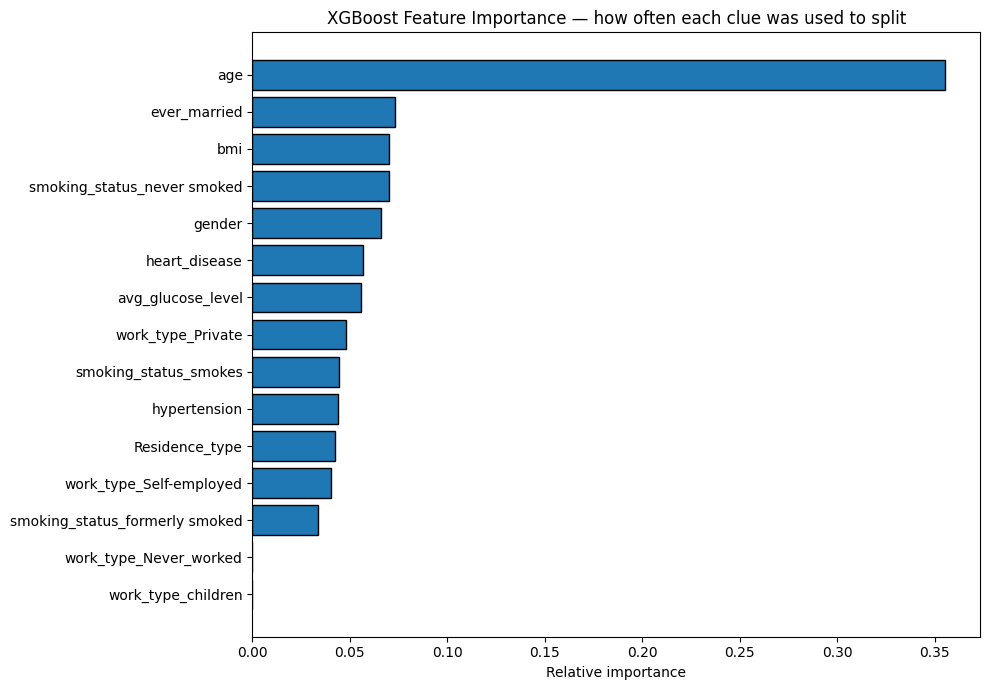


SHAP summary: each dot is one person. Colour = feature value, position = impact on prediction.


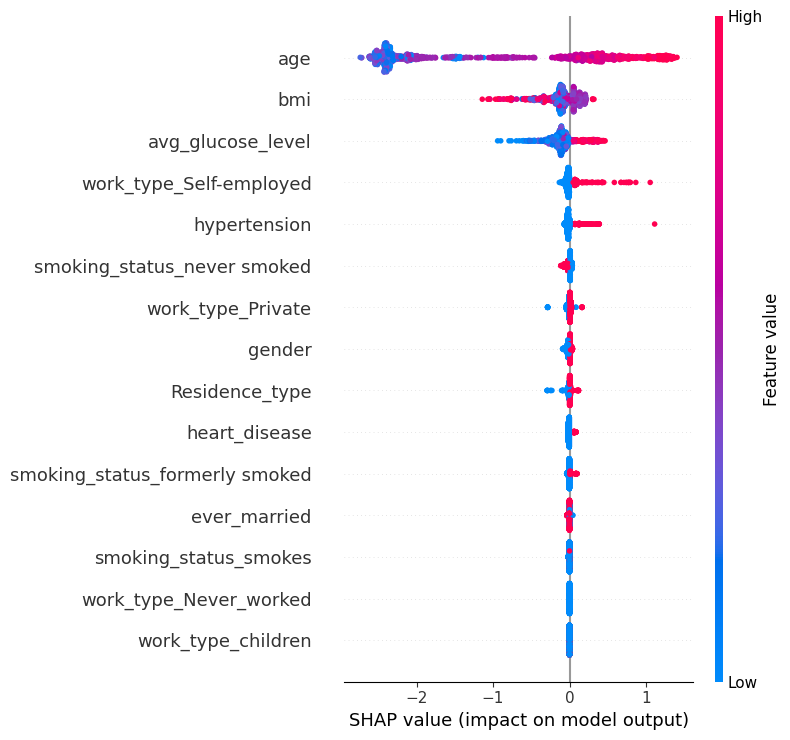

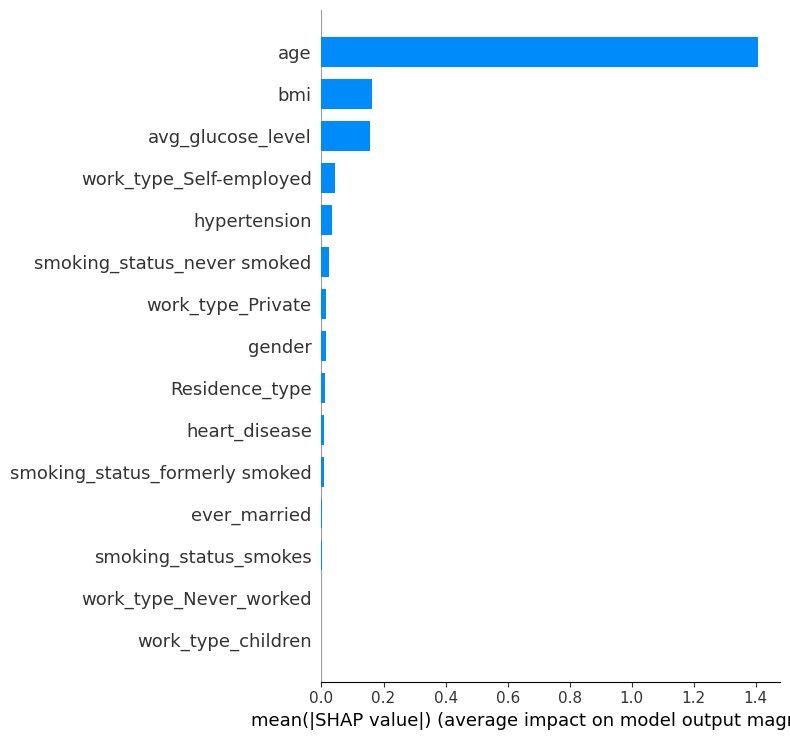

In [ ]:
# Install if needed (Colab usually has it)
# !pip install xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, average_precision_score)

# ============================================================
# 1. PREP (same as before)
# ============================================================
df_xgb = df.copy()
df_xgb['bmi'] = pd.to_numeric(df_xgb['bmi'], errors='coerce')
df_xgb['bmi'] = df_xgb['bmi'].fillna(df_xgb['bmi'].median())
df_xgb = df_xgb.drop(columns=['id'])
df_xgb = df_xgb[df_xgb['gender'] != 'Other']

df_xgb['gender'] = df_xgb['gender'].map({'Male': 0, 'Female': 1})
df_xgb['ever_married'] = df_xgb['ever_married'].map({'No': 0, 'Yes': 1})
df_xgb['Residence_type'] = df_xgb['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_xgb = pd.get_dummies(df_xgb, columns=['work_type', 'smoking_status'], drop_first=True)

X = df_xgb.drop(columns=['stroke'])
y = df_xgb['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# No scaling needed — trees don't care about scale
# Handle imbalance with scale_pos_weight = (negatives / positives)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (up-weights strokes by this factor)")

# ============================================================
# 2. FIT XGBOOST
# ============================================================
model = xgb.XGBClassifier(
    n_estimators=500,          # up to 500 "doctors"
    max_depth=4,               # each doctor asks up to 4 yes/no questions
    learning_rate=0.05,        # each doctor's correction is small (prevents overfitting)
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=30,  # stop adding doctors if no improvement
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print(f"Best iteration: {model.best_iteration}  (stopped adding trees here)")

# ============================================================
# 3. EVALUATE
# ============================================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
print(f"\nROC-AUC: {auc:.3f}   |   PR-AUC: {ap:.3f}")
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

# ============================================================
# 4. THE THREE DIAGNOSTIC CHARTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#d62728', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#2ca02c', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# ============================================================
# 5. FEATURE IMPORTANCE — which "clues" did the doctors use most?
# ============================================================
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'], importance_df['importance'], color='#1f77b4', edgecolor='black')
plt.title('XGBoost Feature Importance — how often each clue was used to split')
plt.xlabel('Relative importance')
plt.tight_layout()
plt.show()

# ============================================================
# 6. SHAP VALUES — the good stuff
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — direction AND magnitude of each feature's impact
print("\nSHAP summary: each dot is one person. Colour = feature value, position = impact on prediction.")
shap.summary_plot(shap_values, X_test, show=True)

# Bar version — clean ranking
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

RANDOM FORREST

ROC-AUC: 0.816   |   PR-AUC: 0.203

=== Classification report ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.84      0.90      1216
      Stroke       0.16      0.60      0.25        62

    accuracy                           0.83      1278
   macro avg       0.57      0.72      0.58      1278
weighted avg       0.94      0.83      0.87      1278



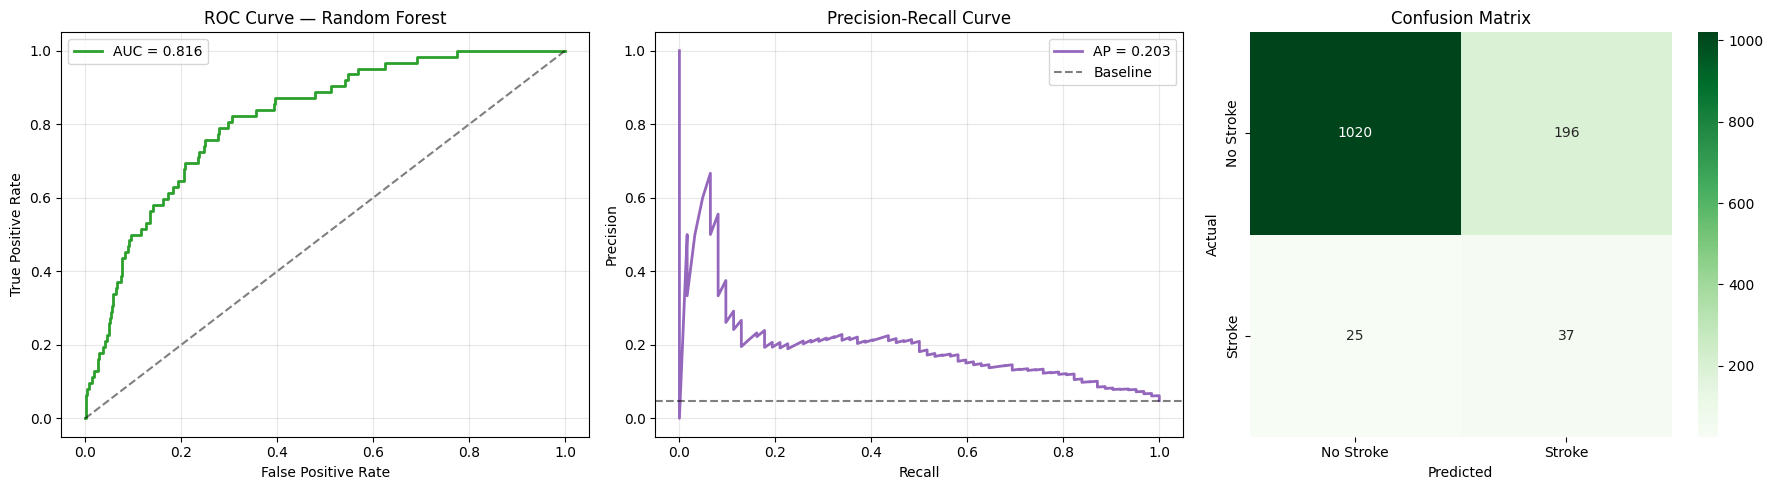

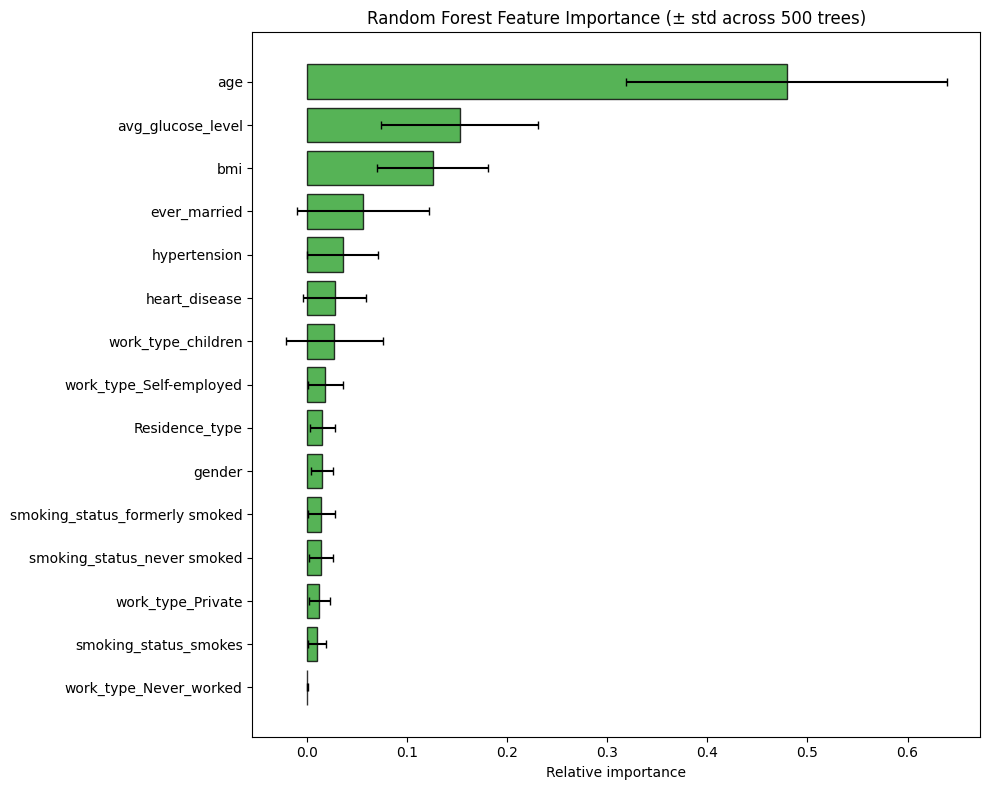

ValueError: cannot reshape array of size 1 into shape (2)

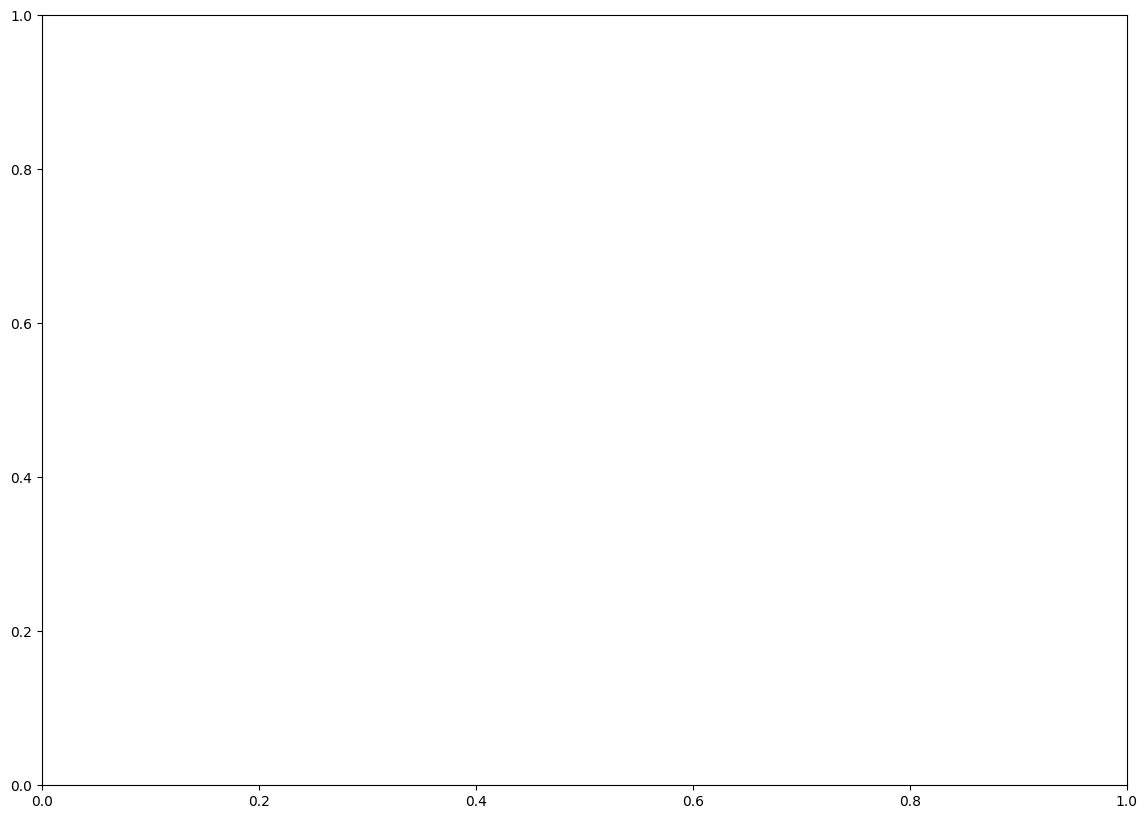

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report,
                             average_precision_score)
import shap

# ============================================================
# 1. PREP (same as before)
# ============================================================
df_rf = df.copy()
df_rf['bmi'] = pd.to_numeric(df_rf['bmi'], errors='coerce')
df_rf['bmi'] = df_rf['bmi'].fillna(df_rf['bmi'].median())
df_rf = df_rf.drop(columns=['id'])
df_rf = df_rf[df_rf['gender'] != 'Other']

df_rf['gender'] = df_rf['gender'].map({'Male': 0, 'Female': 1})
df_rf['ever_married'] = df_rf['ever_married'].map({'No': 0, 'Yes': 1})
df_rf['Residence_type'] = df_rf['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_rf = pd.get_dummies(df_rf, columns=['work_type', 'smoking_status'], drop_first=True)

X = df_rf.drop(columns=['stroke'])
y = df_rf['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ============================================================
# 2. FIT RANDOM FOREST
# ============================================================
model = RandomForestClassifier(
    n_estimators=500,           # 500 trees voting
    max_depth=8,                # deeper than XGBoost — RF individual trees can be bigger
    min_samples_leaf=5,         # prevents overfitting to tiny groups
    class_weight='balanced',    # handles the 5% imbalance
    n_jobs=-1,                  # use all CPU cores
    random_state=42
)
model.fit(X_train, y_train)

# ============================================================
# 3. EVALUATE
# ============================================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}   |   PR-AUC: {ap:.3f}")
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

# ============================================================
# 4. STANDARD DIAGNOSTIC TRIO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#2ca02c', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#9467bd', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# ============================================================
# 5. FEATURE IMPORTANCE — with error bars (RF's superpower)
# ============================================================
# RF gives you importance per tree, so you can compute a std dev across trees
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances,
    'std': std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], xerr=imp_df['std'],
         color='#2ca02c', edgecolor='black', alpha=0.8,
         error_kw={'ecolor': 'black', 'capsize': 3})
plt.title('Random Forest Feature Importance (± std across 500 trees)')
plt.xlabel('Relative importance')
plt.tight_layout()
plt.show()

# ============================================================
# 6. PARTIAL DEPENDENCE PLOTS — the shape of each relationship
# ============================================================
# This is the killer chart for you — shows the FUNCTIONAL FORM
# of how each feature drives predictions
top_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension']

fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    model, X_train, features=top_features,
    kind='average', n_cols=2, ax=ax, target=1,
    line_kw={'color': '#d62728', 'linewidth': 2}
)
plt.suptitle('Partial Dependence — how each feature drives stroke probability', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# 7. SHAP FOR RANDOM FOREST
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values_all = explainer.shap_values(X_test)

# sklearn RF returns shape (n_samples, n_features, n_classes) — take class 1 (stroke)
if isinstance(shap_values_all, list):
    shap_values = shap_values_all[1]
elif shap_values_all.ndim == 3:
    shap_values = shap_values_all[:, :, 1]
else:
    shap_values = shap_values_all

shap.summary_plot(shap_values, X_test, show=True)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

# ============================================================
# 8. THREE-WAY MODEL COMPARISON (if you saved the other predictions)
# ============================================================
# Uncomment if you still have y_pred_proba_logistic and y_pred_proba_xgb in memory
# plt.figure(figsize=(10, 6))
# for name, proba, color in [
#     ('Logistic', y_pred_proba_logistic, '#1f77b4'),
#     ('XGBoost', y_pred_proba_xgb, '#d62728'),
#     ('Random Forest', y_pred_proba, '#2ca02c')
# ]:
#     fpr, tpr, _ = roc_curve(y_test, proba)
#     auc_x = roc_auc_score(y_test, proba)
#     plt.plot(fpr, tpr, label=f'{name} AUC={auc_x:.3f}', linewidth=2, color=color)
# plt.plot([0,1],[0,1],'k--',alpha=0.4)
# plt.title('Three-way model shootout'); plt.legend(); plt.grid(alpha=0.3)
# plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
# plt.tight_layout(); plt.show()

NAIVE BAYES

ROC-AUC: 0.797   |   PR-AUC: 0.177   |   Brier: 0.739

=== Classification report ===
              precision    recall  f1-score   support

   No Stroke       1.00      0.19      0.32      1216
      Stroke       0.06      0.98      0.11        62

    accuracy                           0.23      1278
   macro avg       0.53      0.59      0.22      1278
weighted avg       0.95      0.23      0.31      1278



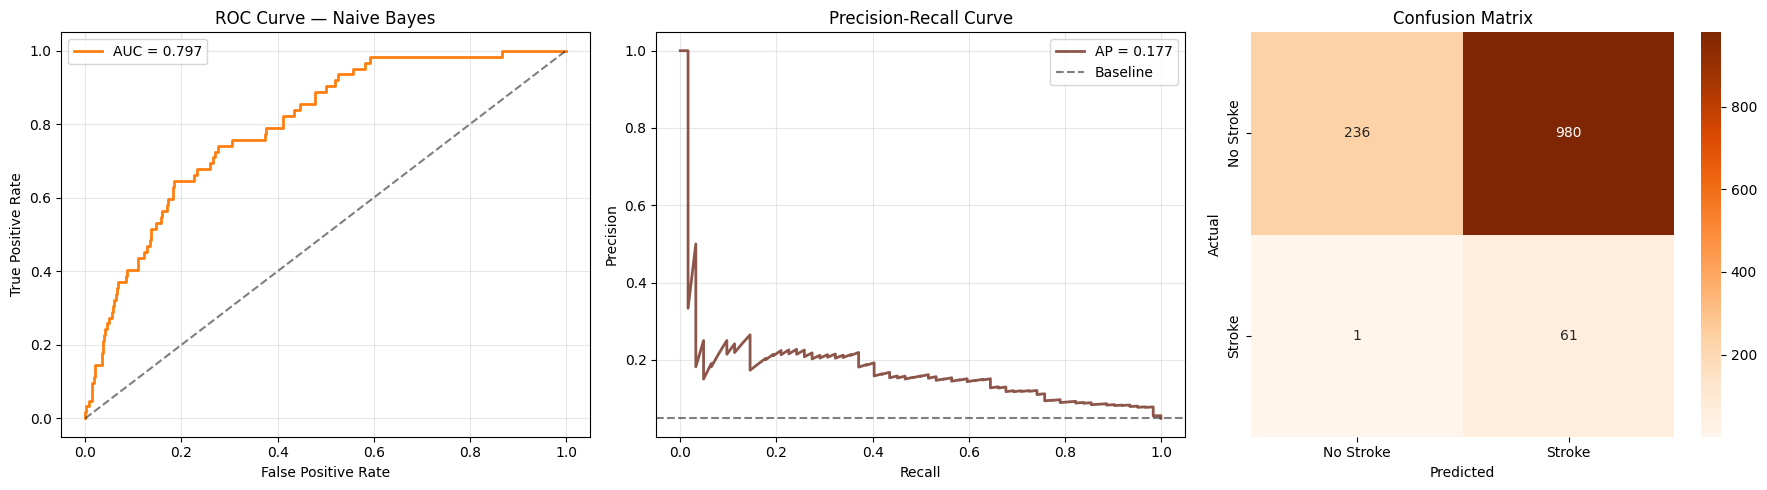

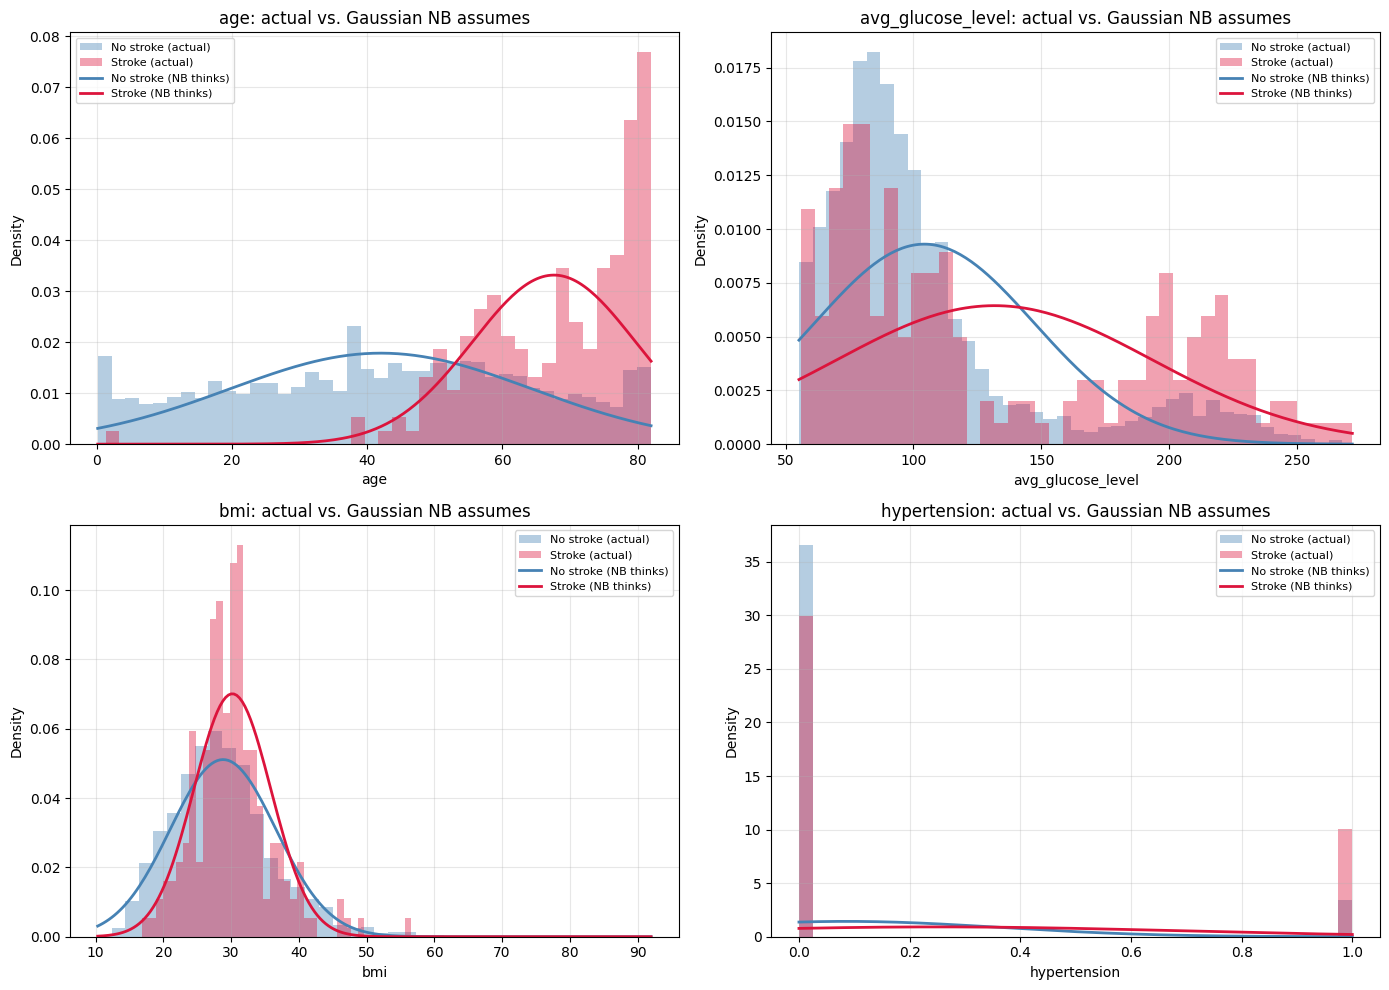

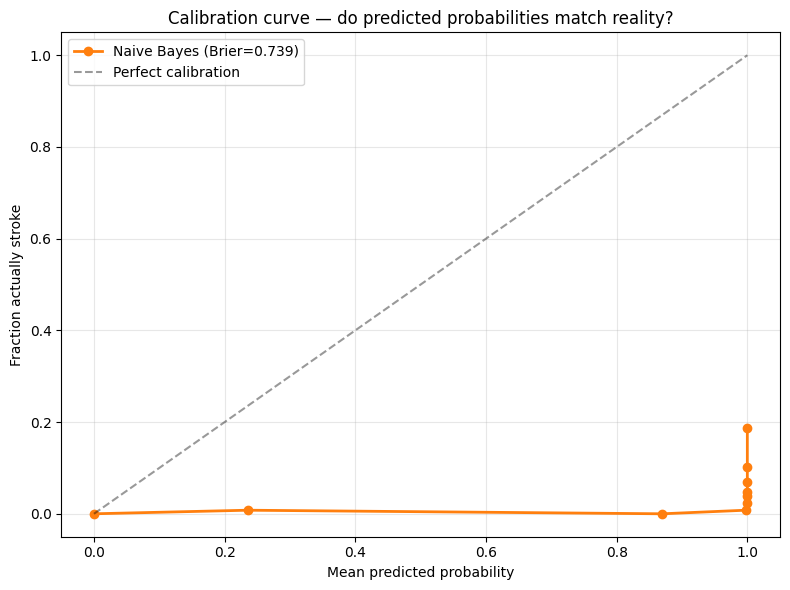

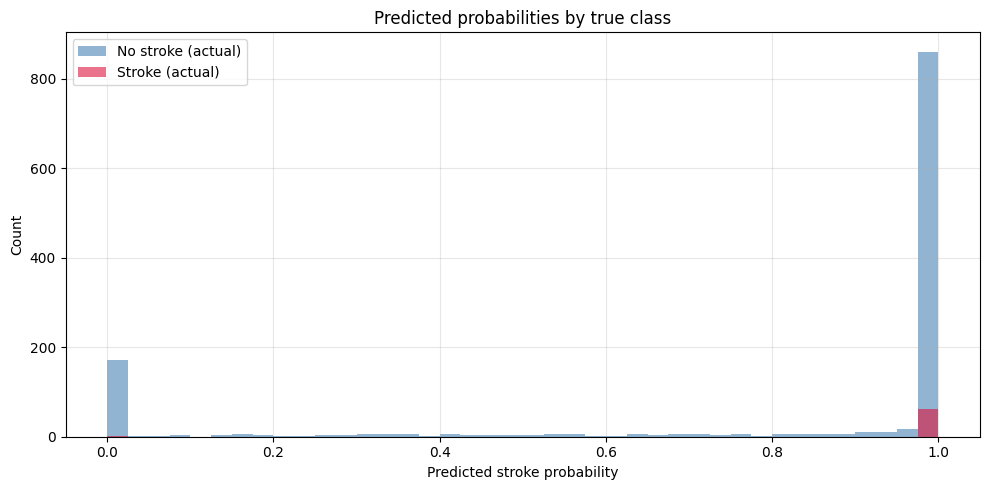

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report,
                             average_precision_score, brier_score_loss)
from sklearn.calibration import calibration_curve

# ============================================================
# 1. PREP (same as before)
# ============================================================
df_nb = df.copy()
df_nb['bmi'] = pd.to_numeric(df_nb['bmi'], errors='coerce')
df_nb['bmi'] = df_nb['bmi'].fillna(df_nb['bmi'].median())
df_nb = df_nb.drop(columns=['id'])
df_nb = df_nb[df_nb['gender'] != 'Other']

df_nb['gender'] = df_nb['gender'].map({'Male': 0, 'Female': 1})
df_nb['ever_married'] = df_nb['ever_married'].map({'No': 0, 'Yes': 1})
df_nb['Residence_type'] = df_nb['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_nb = pd.get_dummies(df_nb, columns=['work_type', 'smoking_status'], drop_first=True)

X = df_nb.drop(columns=['stroke'])
y = df_nb['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# NB doesn't strictly need scaling but it makes the density plots cleaner
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ============================================================
# 2. FIT NAIVE BAYES
# ============================================================
# priors=[0.5, 0.5] tells the model to weight both classes equally
# — the NB equivalent of class_weight='balanced'
model = GaussianNB(priors=[0.5, 0.5])
model.fit(X_train_s, y_train)

# ============================================================
# 3. EVALUATE
# ============================================================
y_pred_proba = model.predict_proba(X_test_s)[:, 1]
y_pred = model.predict(X_test_s)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}   |   PR-AUC: {ap:.3f}   |   Brier: {brier:.3f}")
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))

# ============================================================
# 4. STANDARD DIAGNOSTIC TRIO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#ff7f0e', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Naive Bayes'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#8c564b', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# ============================================================
# 5. THE NB SIGNATURE CHART — learned distributions per feature
# ============================================================
# NB's whole worldview: it fits a bell curve to each feature, per class.
# This chart literally shows you WHAT THE MODEL THINKS the world looks like.
top_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    # Plot actual distributions
    ax.hist(X_train[y_train==0][feat], bins=40, alpha=0.4, color='steelblue',
            density=True, label='No stroke (actual)')
    ax.hist(X_train[y_train==1][feat], bins=40, alpha=0.4, color='crimson',
            density=True, label='Stroke (actual)')

    # Overlay the Gaussian NB thinks each class has
    feat_idx = list(X.columns).index(feat)
    mean_0 = X_train[y_train==0][feat].mean()
    std_0  = X_train[y_train==0][feat].std()
    mean_1 = X_train[y_train==1][feat].mean()
    std_1  = X_train[y_train==1][feat].std()

    x_range = np.linspace(X_train[feat].min(), X_train[feat].max(), 200)
    gauss_0 = (1/(std_0*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range-mean_0)/std_0)**2)
    gauss_1 = (1/(std_1*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range-mean_1)/std_1)**2)

    ax.plot(x_range, gauss_0, color='steelblue', linewidth=2, label='No stroke (NB thinks)')
    ax.plot(x_range, gauss_1, color='crimson', linewidth=2, label='Stroke (NB thinks)')
    ax.set_title(f'{feat}: actual vs. Gaussian NB assumes')
    ax.set_xlabel(feat); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 6. CALIBRATION — NB's known weakness
# ============================================================
plt.figure(figsize=(8, 6))
frac_pos, mean_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')
plt.plot(mean_pred, frac_pos, 'o-', color='#ff7f0e', linewidth=2, label=f'Naive Bayes (Brier={brier:.3f})')
plt.plot([0,1],[0,1],'k--',alpha=0.4, label='Perfect calibration')
plt.title('Calibration curve — do predicted probabilities match reality?')
plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction actually stroke')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7. PROBABILITY DISTRIBUTION BY CLASS
# ============================================================
plt.figure(figsize=(10, 5))
plt.hist(y_pred_proba[y_test==0], bins=40, alpha=0.6, color='steelblue', label='No stroke (actual)')
plt.hist(y_pred_proba[y_test==1], bins=40, alpha=0.6, color='crimson', label='Stroke (actual)')
plt.xlabel('Predicted stroke probability')
plt.ylabel('Count')
plt.title('Predicted probabilities by true class')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ENSEMBLE METHOD

Performance-based weights:
  Logistic: 0.258
  XGBoost: 0.248
  Random Forest: 0.250
  Naive Bayes: 0.244

Stacking meta-model coefficients (which base models it trusts most):
  Logistic: +3.135
  XGBoost: +0.366
  Random Forest: +1.871
  Naive Bayes: +1.460

=== LEADERBOARD ===
                Model  ROC-AUC   PR-AUC    Brier
             Logistic 0.844665 0.260394 0.172718
             Stacking 0.843047 0.245294 0.181527
Voting (AUC-weighted) 0.838471 0.207636 0.193683
       Voting (equal) 0.837861 0.206067 0.195586
        Random Forest 0.815776 0.202997 0.109776
              XGBoost 0.810815 0.177654 0.100843
          Naive Bayes 0.796928 0.177383 0.739176


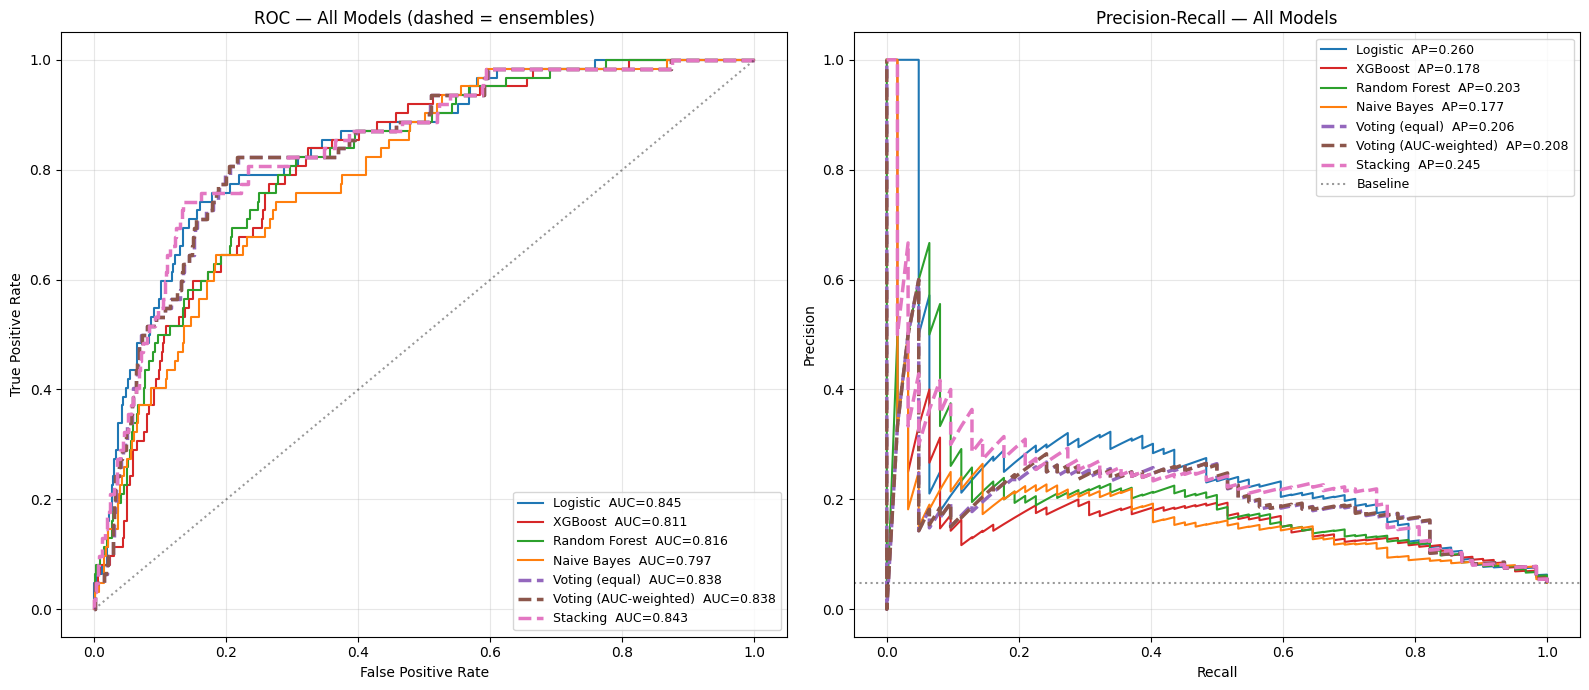

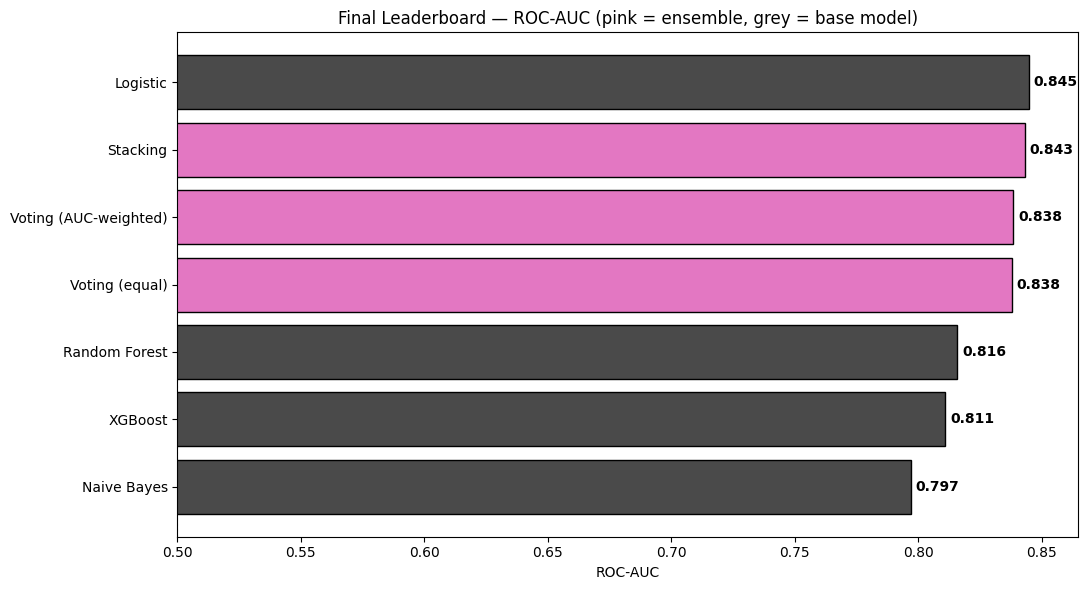

/tmp/ipykernel_670/3831118911.py:212: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(mean_pred, frac_pos, 'o-', label=f'{name}  Brier={brier:.3f}',
/tmp/ipykernel_670/3831118911.py:212: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(mean_pred, frac_pos, 'o-', label=f'{name}  Brier={brier:.3f}',
/tmp/ipykernel_670/3831118911.py:212: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(mean_pred, frac_pos, 'o-', label=f'{name}  Brier={brier:.3f}',
/tmp/ipykernel_670/3831118911.py:212: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle

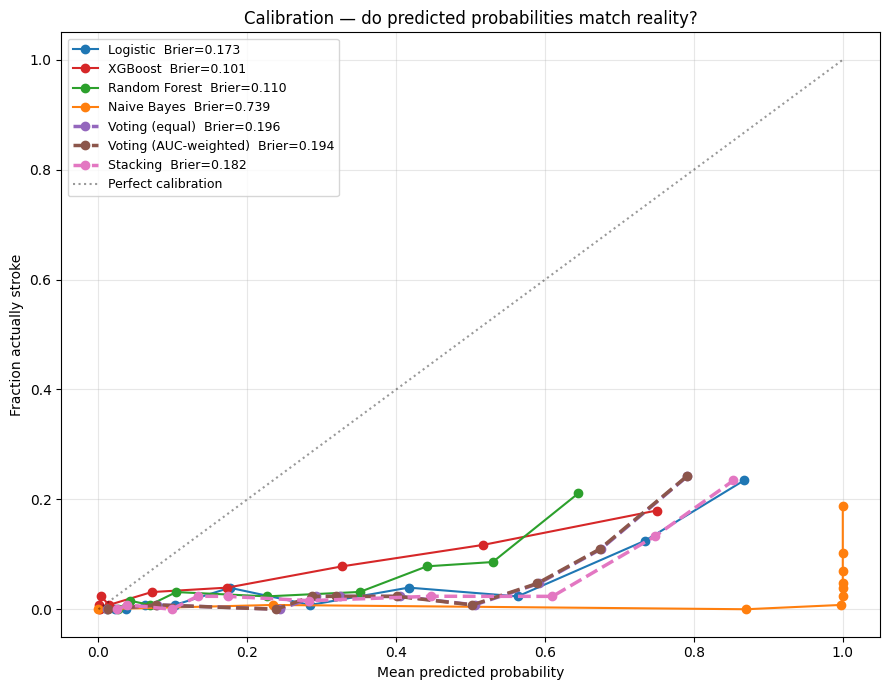

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve

# ============================================================
# 1. PREP (same as before)
# ============================================================
df_ens = df.copy()
df_ens['bmi'] = pd.to_numeric(df_ens['bmi'], errors='coerce')
df_ens['bmi'] = df_ens['bmi'].fillna(df_ens['bmi'].median())
df_ens = df_ens.drop(columns=['id'])
df_ens = df_ens[df_ens['gender'] != 'Other']

df_ens['gender'] = df_ens['gender'].map({'Male': 0, 'Female': 1})
df_ens['ever_married'] = df_ens['ever_married'].map({'No': 0, 'Yes': 1})
df_ens['Residence_type'] = df_ens['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_ens = pd.get_dummies(df_ens, columns=['work_type', 'smoking_status'], drop_first=True)

X = df_ens.drop(columns=['stroke'])
y = df_ens['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Scale for the linear/NB models — trees don't need it but scaling doesn't hurt them
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_s = pd.DataFrame(X_train_s, columns=X.columns)
X_test_s = pd.DataFrame(X_test_s, columns=X.columns)

# ============================================================
# 2. BUILD ALL FOUR BASE MODELS
# ============================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

logistic = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
xgboost_ = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             scale_pos_weight=scale_pos_weight, eval_metric='auc',
                             random_state=42, verbosity=0)
rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=5,
                            class_weight='balanced', n_jobs=-1, random_state=42)
nb = GaussianNB(priors=[0.5, 0.5])

# ============================================================
# 3. FIT INDIVIDUAL MODELS + GET PROBABILITIES
# ============================================================
predictions = {}

for name, m in [('Logistic', logistic), ('XGBoost', xgboost_),
                ('Random Forest', rf), ('Naive Bayes', nb)]:
    m.fit(X_train_s, y_train)
    predictions[name] = m.predict_proba(X_test_s)[:, 1]

# ============================================================
# 4. ENSEMBLE 1 — SIMPLE SOFT VOTING (equal weights)
# ============================================================
predictions['Voting (equal)'] = np.mean([
    predictions['Logistic'],
    predictions['XGBoost'],
    predictions['Random Forest'],
    predictions['Naive Bayes']
], axis=0)

# ============================================================
# 5. ENSEMBLE 2 — AUC-WEIGHTED VOTING
# ============================================================
# Weight each model by its individual AUC — like performance-weighting strategies
aucs = {name: roc_auc_score(y_test, p)
        for name, p in predictions.items() if name not in ['Voting (equal)']}
weights = np.array([aucs['Logistic'], aucs['XGBoost'],
                    aucs['Random Forest'], aucs['Naive Bayes']])
weights = weights / weights.sum()

print("Performance-based weights:")
for name, w in zip(['Logistic', 'XGBoost', 'Random Forest', 'Naive Bayes'], weights):
    print(f"  {name}: {w:.3f}")

predictions['Voting (AUC-weighted)'] = (
    weights[0] * predictions['Logistic'] +
    weights[1] * predictions['XGBoost'] +
    weights[2] * predictions['Random Forest'] +
    weights[3] * predictions['Naive Bayes']
)

# ============================================================
# 6. ENSEMBLE 3 — STACKING (meta-model learns optimal weights)
# ============================================================
# Uses cross-validated predictions from base models as features
# for a final logistic regression meta-learner
stack = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   scale_pos_weight=scale_pos_weight, eval_metric='auc',
                                   random_state=42, verbosity=0)),
        ('rf', RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=5,
                                      class_weight='balanced', n_jobs=-1, random_state=42)),
        ('nb', GaussianNB(priors=[0.5, 0.5]))
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=5,      # 5-fold CV to generate meta-features
    n_jobs=-1
)
stack.fit(X_train_s, y_train)
predictions['Stacking'] = stack.predict_proba(X_test_s)[:, 1]

# Reveal the stacking meta-model's learned weights
print("\nStacking meta-model coefficients (which base models it trusts most):")
meta_coefs = stack.final_estimator_.coef_[0]
for name, c in zip(['Logistic', 'XGBoost', 'Random Forest', 'Naive Bayes'], meta_coefs):
    print(f"  {name}: {c:+.3f}")

# ============================================================
# 7. LEADERBOARD
# ============================================================
results = []
for name, proba in predictions.items():
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'Brier': brier_score_loss(y_test, proba)
    })
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n=== LEADERBOARD ===")
print(results_df.to_string(index=False))

# ============================================================
# 8. THE MONEY SHOT — HEAD-TO-HEAD ROC + PR OVERLAY
# ============================================================
colors = {
    'Logistic': '#1f77b4', 'XGBoost': '#d62728',
    'Random Forest': '#2ca02c', 'Naive Bayes': '#ff7f0e',
    'Voting (equal)': '#9467bd', 'Voting (AUC-weighted)': '#8c564b',
    'Stacking': '#e377c2'
}
styles = {
    'Logistic': '-', 'XGBoost': '-', 'Random Forest': '-', 'Naive Bayes': '-',
    'Voting (equal)': '--', 'Voting (AUC-weighted)': '--', 'Stacking': '--'
}
widths = {
    'Logistic': 1.5, 'XGBoost': 1.5, 'Random Forest': 1.5, 'Naive Bayes': 1.5,
    'Voting (equal)': 2.5, 'Voting (AUC-weighted)': 2.5, 'Stacking': 2.5
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
for name, proba in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_ = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name}  AUC={auc_:.3f}',
                 color=colors[name], linestyle=styles[name], linewidth=widths[name])
axes[0].plot([0,1],[0,1],'k:',alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC — All Models (dashed = ensembles)')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(alpha=0.3)

# PR
for name, proba in predictions.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name}  AP={ap:.3f}',
                 color=colors[name], linestyle=styles[name], linewidth=widths[name])
axes[1].axhline(y_test.mean(), color='k', linestyle=':', alpha=0.4, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — All Models')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 9. LEADERBOARD AS A CHART
# ============================================================
plt.figure(figsize=(11, 6))
plot_df = results_df.sort_values('ROC-AUC', ascending=True)
bar_colors = ['#e377c2' if 'Stacking' in n or 'Voting' in n else '#4a4a4a'
              for n in plot_df['Model']]
bars = plt.barh(plot_df['Model'], plot_df['ROC-AUC'], color=bar_colors, edgecolor='black')
plt.axvline(0.5, color='k', linestyle=':', alpha=0.4, label='Random guess')
for bar, auc_ in zip(bars, plot_df['ROC-AUC']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{auc_:.3f}', va='center', fontsize=10, fontweight='bold')
plt.title('Final Leaderboard — ROC-AUC (pink = ensemble, grey = base model)', fontsize=12)
plt.xlabel('ROC-AUC'); plt.xlim(0.5, max(plot_df['ROC-AUC']) + 0.02)
plt.tight_layout()
plt.show()

# ============================================================
# 10. CALIBRATION COMPARISON — probability quality
# ============================================================
plt.figure(figsize=(9, 7))
for name, proba in predictions.items():
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, proba)
    plt.plot(mean_pred, frac_pos, 'o-', label=f'{name}  Brier={brier:.3f}',
             color=colors[name], linestyle=styles[name], linewidth=widths[name])
plt.plot([0,1],[0,1],'k:',alpha=0.4, label='Perfect calibration')
plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction actually stroke')
plt.title('Calibration — do predicted probabilities match reality?')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()